In [1]:
import numpy as np
import matplotlib.pylab as plt
from parameters import * # import parameters and units
import brian2 as brian # import the whole module

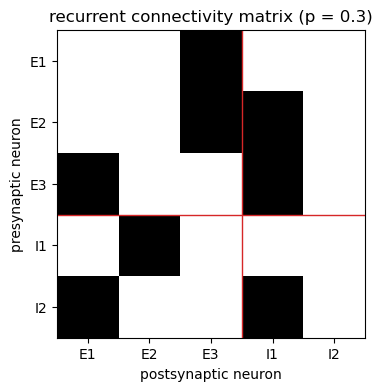

In [2]:
np.random.seed(3)  # reproducible connectivity + external events

# --- network size ---
N_E, N_I = 3, 2
N = N_E + N_I  # neuron indices: 0,1,2 = excitatory, 3,4 = inhibitory

# --- random recurrent connectivity matrix, 30% pairwise probability, no autapses ---
conn = np.random.rand(N, N) < 0.3
np.fill_diagonal(conn, False)
pre_idx, post_idx = np.nonzero(conn)

nrn_labels = ['E1', 'E2', 'E3', 'I1', 'I2']

fig, ax_c = plt.subplots(figsize=(4,4))
ax_c.imshow(conn, cmap='Greys', vmin=0, vmax=1)
ax_c.set_xticks(range(N), labels=nrn_labels)
ax_c.set_yticks(range(N), labels=nrn_labels)
ax_c.set_xlabel('postsynaptic neuron'); ax_c.set_ylabel('presynaptic neuron')
ax_c.set_title('recurrent connectivity matrix (p = 0.3)')
for b in [N_E - 0.5]:
    ax_c.axhline(b, color='C3', lw=1); ax_c.axvline(b, color='C3', lw=1)


In [3]:
brian.start_scope()

we    = 3*nS
w_ext = 8*nS
wi    = 20*nS

eqs = '''
dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
dg_e/dt   = -g_e   / tau_e : siemens
dg_i/dt   = -g_i   / tau_i : siemens
dg_ext/dt = -g_ext / tau_e : siemens
'''

pop = brian.NeuronGroup(N, eqs, threshold='v>Vt', reset='v=Vr',
                         method='exponential_euler')
pop.v = El

is_exc_source = pre_idx < N_E
syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

# --- independent external excitatory events, 3-4 per neuron ---
ext_pre, ext_times = [], []
ext_times =[
    [10, 180, 185, 190, 195],
    [20, 70, 75, 80],
    [250, 255, 260],
    [140, 145, 150, 155],
    [110, 115, 120],
]
ext_input = brian.SpikeGeneratorGroup(N, 
                    np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                    np.concatenate(ext_times)*ms)

syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

mon    = brian.StateMonitor(pop, 'v', record=True)
spikes = brian.SpikeMonitor(pop)

brian.run(300*ms)

print(f'Spike counts per neuron: {dict(zip(range(N), spikes.count))}')


Spike counts per neuron: {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


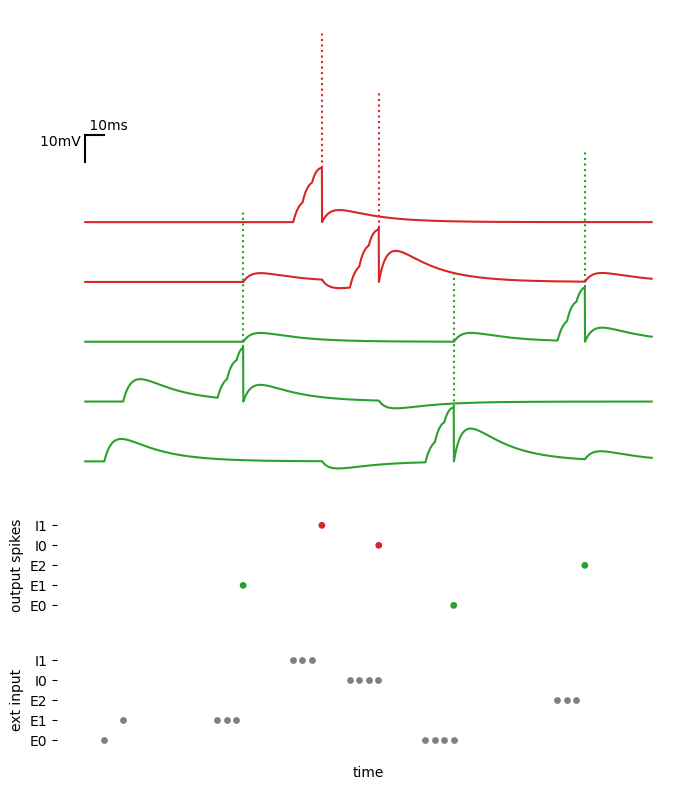

In [4]:
from plots import plot_with_spikes

def plot(ext_times, mon, spikes):
    # --- plot: connectivity matrix, voltage traces, raster ---
    fig = plt.figure(figsize=(7, 8))
    gs = fig.add_gridspec(3, 1, height_ratios=[4, 1, 1])

    ax_v = fig.add_subplot(gs[0], frameon=False)
    colors = ['C2']*N_E + ['C3']*N_I
    for n in range(N):
        label = f'E{n}' if n < N_E else f'I{n - N_E}'
        plot_with_spikes(ax_v, mon, n, shift=n*22, color=colors[n])

    # show bar scale
    ax_v.plot([0,0], El/mV+(n+2)*20-np.arange(2)*10, 'k-')
    ax_v.plot([0,10], El/mV+(n+2)*20-np.zeros(2), 'k-')
    ax_v.annotate('10mV ', (0,El/mV+(n+2)*20), va='top', ha='right', xycoords='data')
    ax_v.annotate(' 10ms', (0,El/mV+(n+2)*20+2), xycoords='data')
    ax_v.legend(loc='upper right', fontsize=7, ncol=5, frameon=False)
    ax_v.axis('off')

    ax_r = fig.add_subplot(gs[1], sharex=ax_v, frameon=False)
    ax_r.scatter(spikes.t/ms, spikes.i, c=[colors[i] for i in spikes.i], s=15)
    ax_r.set_ylabel('output spikes')
    ax_r.set_yticks(range(N), labels=[f'E{n}' if n < N_E else f'I{n - N_E}' for n in range(N)])
    ax_r.set_xticks([])
    ax_r.set_ylim([-1,N])

    ax_e = fig.add_subplot(gs[2], sharex=ax_v, frameon=False)
    ax_e.scatter(np.concatenate(ext_times),
                np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                c='grey', s=15)
    ax_e.set_xlabel('time'); ax_e.set_ylabel('ext input')
    ax_e.set_yticks(range(N), labels=[f'E{n}' if n < N_E else f'I{n - N_E}' for n in range(N)])
    ax_e.set_xticks([])
    ax_e.set_ylim([-1,N])

    plt.tight_layout()

plot(ext_times, mon, spikes)

In [5]:
brian.start_scope()

wi    = 20*nS

eqs = '''
dv/dt = (-gL*(v - El) - (g_e + g_ext)*(v - Ee) - g_i*(v - Ei)) / Cm : volt
dg_e/dt   = -g_e   / tau_e : siemens
dg_i/dt   = -g_i   / tau_i : siemens
dg_ext/dt = -g_ext / tau_e : siemens
'''

pop = brian.NeuronGroup(N, eqs, threshold='v>Vt', reset='v=Vr',
                         method='exponential_euler')
pop.v = El

is_exc_source = pre_idx < N_E
syn_e = brian.Synapses(pop, pop, on_pre='g_e += we')
syn_e.connect(i=pre_idx[is_exc_source], j=post_idx[is_exc_source])
syn_i = brian.Synapses(pop, pop, on_pre='g_i += wi')
syn_i.connect(i=pre_idx[~is_exc_source], j=post_idx[~is_exc_source])

# --- independent external excitatory events, 3-4 per neuron ---
ext_pre, ext_times = [], []
ext_times =[
    np.cumsum(np.random.exponential(10, 20)) for n in range(N)
]
ext_input = brian.SpikeGeneratorGroup(N, 
                    np.concatenate([[n]*len(times) for n, times in enumerate(ext_times)]),
                    np.concatenate(ext_times)*ms)

syn_ext = brian.Synapses(ext_input, pop, on_pre='g_ext += w_ext')
syn_ext.connect(j='i')  # each neuron driven by its own independent ext source

mon    = brian.StateMonitor(pop, 'v', record=True)
spikes = brian.SpikeMonitor(pop)

brian.run(300*ms)

print(f'Spike counts per neuron: {dict(zip(range(N), spikes.count))}')


Spike counts per neuron: {0: 5, 1: 6, 2: 8, 3: 4, 4: 6}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


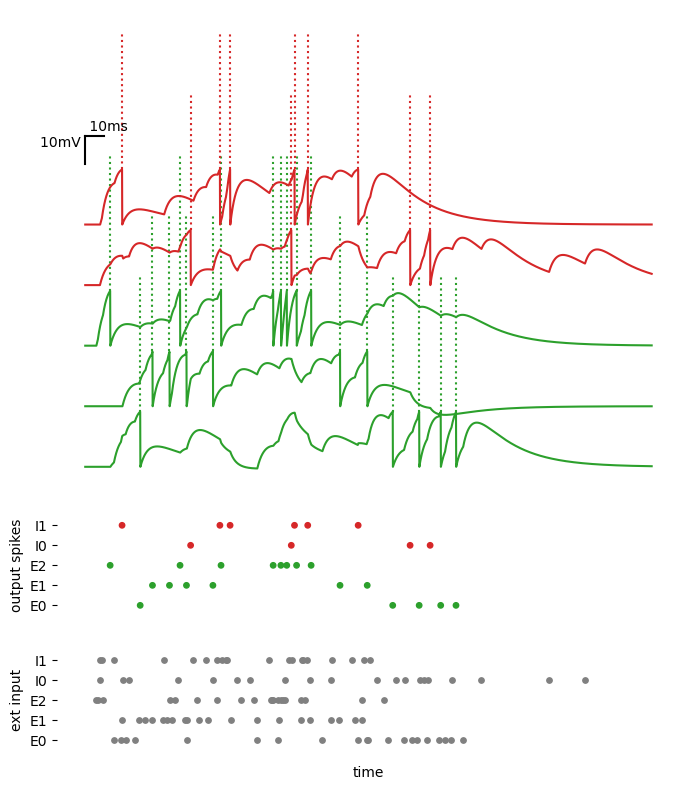

In [6]:
plot(ext_times, mon, spikes)